<a href="https://colab.research.google.com/github/Helen13JS/SIS420_Inteligencia_Artificial/blob/main/Laboratorios/Laboratorio3/Lab3_clasificacion_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio de Programación - Regresión Logística
Helen Janko Sanga Ing. Sistemas
## Dataset: Diabetes 130-US Hospitals (1999-2008)
##link : https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008

En este ejercicio se implementa regresión logística y se aplica al dataset de readmisión hospitalaria de pacientes diabéticos.

**Objetivo:** Predecir si un paciente será readmitido sea en menos de 30 días o mas.
- `1` = readmitido
- `0` = no readmitido

##1 — Montar Drive e Importar Librerías
Se monta Google Drive para acceder al dataset y se importan las librerías necesarias:
- `numpy` para cálculo vectorial
- `pandas` para manejo del CSV
- `matplotlib` para graficar
- `scipy.optimize` para la optimización del modelo

In [19]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
from matplotlib import pyplot
from scipy import optimize
%matplotlib inline

print(' Librerías cargadas correctamente')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Librerías cargadas correctamente


## 2 — Carga del Dataset
Se carga el archivo CSV desde Google Drive.
El dataset fue parcialmente limpiado en Excel:
- Columnas innecesarias ya eliminadas
- Filas con `?` en `race` ya eliminadas
- Filas con `Unknown/Invalid` en `gender` ya eliminadas
- Columna `readmitted_bin` ya creada (1 = `<30 o >30 admitidos`, 0 = resto)

Se imprime la forma del dataset y las primeras filas para verificar que cargó correctamente.

In [20]:
# *** CAMBIA ESTA RUTA por la ruta real de tu archivo en Drive ***
df = pd.read_csv('/content/drive/MyDrive/Colab_Projects_AI/datasets/diabetes.csv',sep=';')

print('=== INFORMACIÓN GENERAL ===')
print(f'Forma del dataset: {df.shape}')
print(f'Columnas: {list(df.columns)}')
print()
print(df.head())

=== INFORMACIÓN GENERAL ===
Forma del dataset: (99492, 41)
Columnas: ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'readmitted_bin']

              race  gender      age  admission_type_id  \
0        Caucasian  Female  [10-20)                  6   
1        Caucasian    Male  [10-20)                  1   
2  AfricanAmerican  Female  [20-30)                 

## 3 — Limpieza Final en Python

El modelo de regresión logística solo trabaja con valores numéricos,
por lo que todas las variables categóricas deben convertirse antes del entrenamiento.

- `readmitted_bin` se redefine como 1 si el paciente fue readmitido en cualquier momento
  y 0 si no fue readmitido. Esto resuelve el desbalance severo del target original.
- `age` se convierte al punto medio de cada intervalo porque es una variable continua ordenada.
- `gender`, `change`, `diabetesMed` se convierten a 1/0 por ser variables binarias.
- `max_glu_serum` y `A1Cresult` se mapean a escala 0-3 donde 0 significa que el examen
  no fue realizado — información clínicamente válida.
- Los 21 medicamentos se mapean a escala 0-3: No uso, Estable, Aumentado, Disminuido.
- `race` se convierte a columnas dummies porque es variable nominal — no tiene orden natural.
- Se eliminan filas con valores NaN residuales

In [21]:
# Eliminar duplicados primero
df = df.drop_duplicates()

#  NUEVO TARGET antes de eliminar readmitted
df['readmitted_bin'] = (df['readmitted'] != 'NO').astype(int)

# Ahora sí eliminar readmitted original
df = df.drop(columns=['readmitted'], errors='ignore')

# Rellenar NaN en columnas categóricas ANTES de mapear
df['max_glu_serum'] = df['max_glu_serum'].fillna('None')
df['A1Cresult']     = df['A1Cresult'].fillna('None')

# age → numérico
age_map = {
    '[0-10)':5,  '[10-20)':15, '[20-30)':25, '[30-40)':35,
    '[40-50)':45,'[50-60)':55, '[60-70)':65, '[70-80)':75,
    '[80-90)':85,'[90-100)':95
}
df['age'] = df['age'].map(age_map)

# gender, change, diabetesMed → 1/0
df['gender']      = (df['gender']      == 'Male').astype(int)
df['change']      = (df['change']      == 'Ch').astype(int)
df['diabetesMed'] = (df['diabetesMed'] == 'Yes').astype(int)

# max_glu_serum y A1Cresult → escala 0-3
glu_map = {'None':0, 'Norm':1, '>200':2, '>300':3}
a1c_map = {'None':0, 'Norm':1, '>7':2,   '>8':3}
df['max_glu_serum'] = df['max_glu_serum'].map(glu_map)
df['A1Cresult']     = df['A1Cresult'].map(a1c_map)

# Medicamentos → escala 0-3
med_map  = {'No':0, 'Steady':1, 'Up':2, 'Down':3}
med_cols = ['metformin','repaglinide','nateglinide','chlorpropamide',
            'glimepiride','acetohexamide','glipizide','glyburide',
            'tolbutamide','pioglitazone','rosiglitazone','acarbose',
            'miglitol','troglitazone','tolazamide','insulin',
            'glyburide-metformin','glipizide-metformin',
            'glimepiride-pioglitazone','metformin-rosiglitazone',
            'metformin-pioglitazone']
for col in med_cols:
    if col in df.columns:
        df[col] = df[col].map(med_map)

# race → dummies
race_dummies = pd.get_dummies(df['race'], prefix='race', drop_first=True)
df = pd.concat([df.drop(columns=['race']), race_dummies], axis=1)

# Convertir todo a numérico y eliminar NaN residuales
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()

print('=== DATASET LIMPIO Y LISTO ===')
print(f'Forma final: {df.shape}')
print(f'Columnas ({len(df.columns)}): {list(df.columns)}')

=== DATASET LIMPIO Y LISTO ===
Forma final: (99486, 43)
Columnas (43): ['gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted_bin', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other']


## 4 — Distribución del Target
Se verifica cuántos pacientes fueron readmitidos en algún momento vs. los que no fueron readmitidos.
Con clases muy desiguales el modelo tiende a predecir siempre
la clase mayoritaria y obtener un accuracy engañoso.
Verificar este balance es el primer paso antes de entrenar.

=== DISTRIBUCIÓN DEL TARGET ===
  0 (No readmitido):  53312 (53.6%)
  1 (Readmitido):     46174 (46.4%)

La distribución es casi equilibrada, lo que indica que el modelo
tendrá suficientes ejemplos de ambas clases para aprender correctamente.


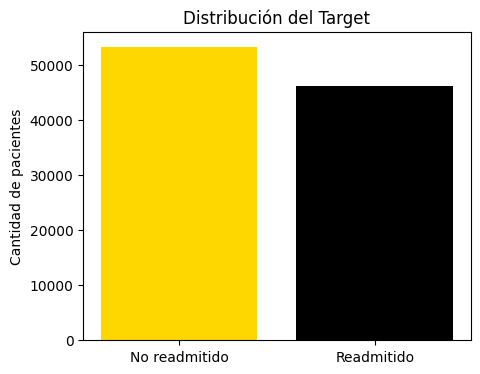

In [22]:
counts = df['readmitted_bin'].value_counts()

print('=== DISTRIBUCIÓN DEL TARGET ===')
print(f'  0 (No readmitido): {counts[0]:6d} ({counts[0]/len(df)*100:.1f}%)')
print(f'  1 (Readmitido):    {counts[1]:6d} ({counts[1]/len(df)*100:.1f}%)')
print()
print('La distribución es casi equilibrada, lo que indica que el modelo')
print('tendrá suficientes ejemplos de ambas clases para aprender correctamente.')

pyplot.figure(figsize=(5, 4))
pyplot.bar(['No readmitido', 'Readmitido'], [counts[0], counts[1]],
           color=['gold', 'black'])
pyplot.title('Distribución del Target')
pyplot.ylabel('Cantidad de pacientes')
pyplot.show()

##  5 — Separar X e y / Split Train-Test
Se separan las features (X) del target (y) como arrays de numpy.
Se realiza un split manual:
- **80%** de los datos para entrenamiento
- **20%** de los datos para prueba

In [23]:
y_all = df['readmitted_bin'].values
X_all = df.drop(columns=['readmitted_bin']).values

# Split manual 80/20
split = int(0.8 * len(X_all))

X_train, y_train = X_all[:split], y_all[:split]
X_test,  y_test  = X_all[split:], y_all[split:]
X = X_train
y = y_train

print(f'Forma de X completo: {X_all.shape}')
print(f'Forma de y completo: {y_all.shape}')
print(f'\nEjemplos de entrenamiento: {X_train.shape[0]}')
print(f'Ejemplos de prueba:        {X_test.shape[0]}')

Forma de X completo: (99486, 42)
Forma de y completo: (99486,)

Ejemplos de entrenamiento: 79588
Ejemplos de prueba:        19898


##  6 — Visualización de los Datos
Se grafican dos features numéricas (`time_in_hospital` vs `num_medications`)
para observar cómo se distribuyen los pacientes readmitidos vs los no readmitidos.
- `*` negro = readmitido
- `o` amarillo = no readmitido

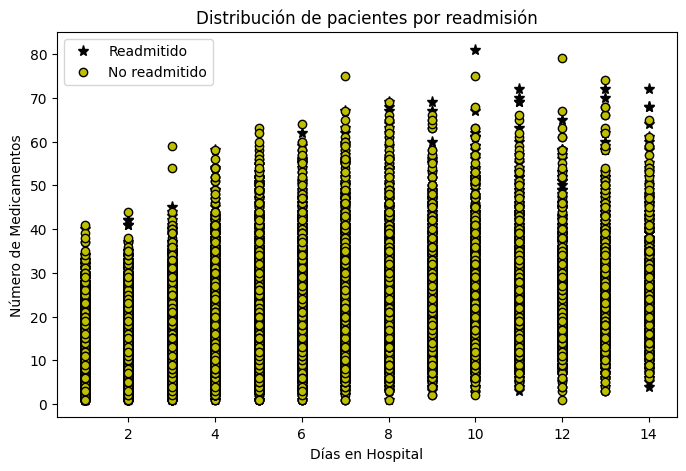

In [24]:
def plotData(X, y, idx1=0, idx2=1):
    fig = pyplot.figure(figsize=(8, 5))
    pos = y == 1
    neg = y == 0
    pyplot.plot(X[pos, idx1], X[pos, idx2], 'k*', lw=2, ms=8)
    pyplot.plot(X[neg, idx1], X[neg, idx2], 'ko', mfc='y', ms=6, mec='k', mew=1)

cols = list(df.drop(columns=['readmitted_bin']).columns)
idx1 = cols.index('time_in_hospital') if 'time_in_hospital' in cols else 0
idx2 = cols.index('num_medications')  if 'num_medications'  in cols else 1

plotData(X_train, y_train, idx1=idx1, idx2=idx2)
pyplot.xlabel('Días en Hospital')
pyplot.ylabel('Número de Medicamentos')
pyplot.legend(['Readmitido', 'No readmitido'])
pyplot.title('Distribución de pacientes por readmisión')
pyplot.show()

##  7 — Función Sigmoide
La hipótesis para la regresión logística se define como:

$$h_\theta(x) = g(\theta^T x)$$

donde $g$ es la función sigmoide:

$$g(z) = \frac{1}{1+e^{-z}}$$

- z grande y positivo → la probabilidad se acerca a 1 (casi seguro readmitido)
- z grande y negativo → la probabilidad se acerca a 0 (casi seguro no readmitido)  
- z = 0 → probabilidad exacta de 0.5 (el modelo no sabe)

In [25]:
def sigmoid(z):
    z = np.array(z)
    g = 1 / (1 + np.exp(-z))
    return g

# Prueba de la función
z = [0, 0.5, 0.75, 1]
g = sigmoid(z)
print(f'g({z}) = {g}')
print(f'sigmoid(0) debe ser exactamente 0.5: {sigmoid(0)}')

g([0, 0.5, 0.75, 1]) = [0.5        0.62245933 0.6791787  0.73105858]
sigmoid(0) debe ser exactamente 0.5: 0.5


##  8 — Normalización de Features
Se normaliza X para que cada feature tenga **media = 0** y **desviación estándar = 1**.
Esto es fundamental para que el descenso por gradiente converja correctamente
cuando las variables tienen escalas muy diferentes.

**Importante:** `mu` y `sigma` se calculan SOLO con el set de entrenamiento
y se reutilizan después para normalizar el set de prueba.

In [26]:
def featureNormalize(X):
    # Asegurar que X sea completamente numérico (float) antes de los cálculos
    X_float = X.copy().astype(float)

    mu     = np.mean(X_float, axis=0)
    sigma  = np.std(X_float, axis=0)

    # Evitar división por cero si la desviación estándar es 0 (para features constantes)
    sigma[sigma == 0] = 1

    X_norm = (X_float - mu) / sigma

    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X_train)

print('Primeras 5 medias (mu):    ', mu[:5])
print('Primeras 5 desv. (sigma):  ', sigma[:5])
print('\nX normalizado (primeras 3 filas):')
print(X_norm[:3])

Primeras 5 medias (mu):     [ 0.45975524 65.67774036  2.10236468  3.92420968  5.86167513]
Primeras 5 desv. (sigma):   [ 0.49837773 16.04208146  1.51248774  5.55711709  4.27847517]

X normalizado (primeras 3 filas):
[[-9.22503583e-01 -3.15905018e+00  2.57696985e+00  3.79257625e+00
  -1.13631023e+00 -1.14850349e+00 -1.20523829e-01 -7.93247855e-01
  -1.82480018e+00 -2.79838015e-01 -2.26449928e-01 -5.07205509e-01
  -3.19730891e+00 -2.34387521e-01 -4.08110586e-01 -4.51409741e-01
  -1.15027017e-01 -7.99529549e-02 -3.07122449e-02 -2.09498372e-01
  -3.54469549e-03 -3.48717196e-01 -3.20607510e-01 -1.62458768e-02
  -2.60720460e-01 -2.67274737e-01 -5.35801120e-02 -1.80919988e-02
  -6.13966983e-03 -2.18834360e-02 -8.39188643e-01 -7.88394780e-02
  -1.27815450e-02 -3.54469549e-03  0.00000000e+00  0.00000000e+00
  -9.03992307e-01 -1.79261194e+00 -7.16946441e-02  5.70385946e-01
  -1.38973107e-01 -1.13940268e-01]
 [ 1.08400663e+00 -3.15905018e+00 -7.28842057e-01 -5.26209837e-01
   2.66058543e-01 -4.869

El output muestra las primeras 5 medias (mu) y desviaciones (sigma) calculadas
del set de entrenamiento. Por ejemplo, la segunda feature (age) tiene media 65.67
años — el paciente típico en este dataset es adulto mayor.
Después de normalizar, todos los valores quedan en escala comparable cerca de 0.

## 9 — Término de Intercepción + Costo Inicial
Se agrega una columna de **unos** a X (término de intercepción $\theta_0$).

La función de costo para regresión logística es:

$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log(h_\theta(x^{(i)})) - (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)})) \right]$$

Con `theta = 0`, el costo esperado es $\log(2) \approx 0.6931$

La verificación clave es que con theta=0, el modelo no sabe nada y asigna
probabilidad 0.5 a todos los pacientes. Sustituyendo en la función de costo
obtenemos -log(0.5) = log(2) = 0.6931. Si este valor no coincide,
indica un error en la implementación de la función de costo.

In [27]:
# Agregar término de intercepción
m, n = X_norm.shape
X_train_norm = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print(f'Forma de X_train con intercepción: {X_train_norm.shape}')

def calcularCosto(theta, X, y):
    m = y.size
    J = 0
    h = sigmoid(X.dot(theta.T))
    h = np.clip(h, 1e-10, 1 - 1e-10)
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    return J

# Verificar costo inicial con theta = 0
theta_init    = np.zeros(X_train_norm.shape[1])
costo_inicial = calcularCosto(theta_init, X_train_norm, y_train)

print(f'\nCosto inicial (theta=0): {costo_inicial:.4f}')
print(f'Costo esperado (log 2):  {np.log(2):.4f}')

Forma de X_train con intercepción: (79588, 43)

Costo inicial (theta=0): 0.6931
Costo esperado (log 2):  0.6931


## 10 — Descenso por Gradiente
Se implementa el descenso por gradiente para optimizar θ partiendo desde cero.
En cada iteración se calcula el error entre la predicción y el valor real,
y se ajustan los parámetros theta en la dirección que reduce ese error.

La regla de actualización es:

$$\theta_j := \theta_j - \alpha \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)}$$

Se entrena con:
- `alpha = 0.01` — tasa de aprendizaje, controla el tamaño del paso en cada iteración
- `num_iters = 4000` — número de veces que se actualiza theta

Se grafica el historial del costo para verificar que el modelo converge.

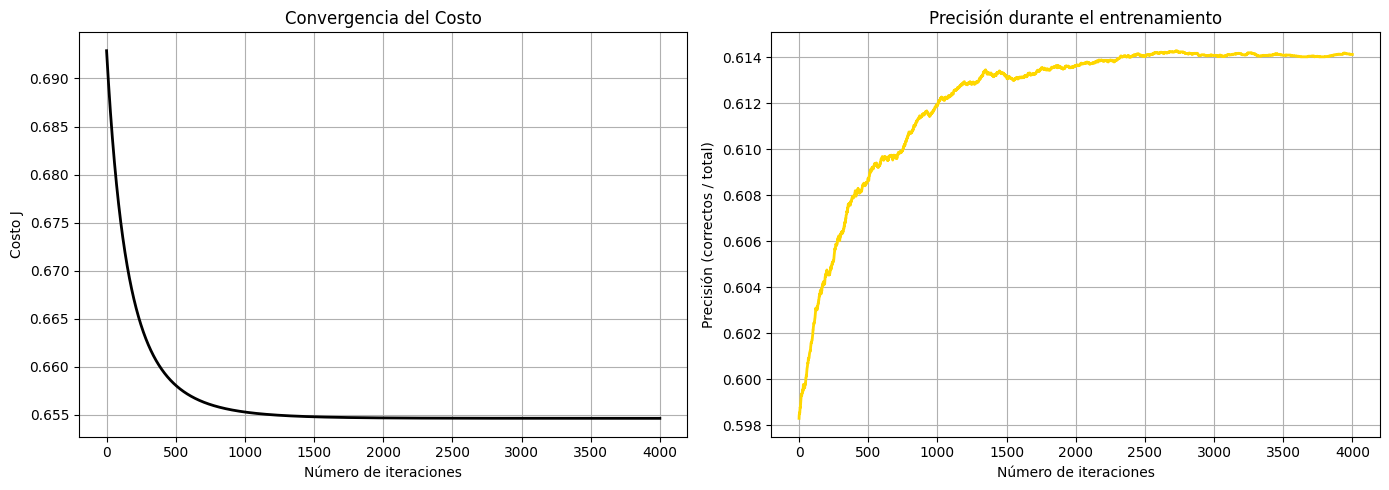

theta calculado por el descenso por el gradiente: [-0.05786209 -0.02525769  0.02910079  0.05445349 -0.08309295] ...
Costo final tras 4000 iteraciones:        0.6546
Precisión final en entrenamiento:  61.41 %


In [28]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    p_history = []
    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))

        # Precisión = suma(y_pred == y_real) / m  ← lo que pediste
        y_pred = np.round(sigmoid(X.dot(theta.T)))
        prec = np.sum(y_pred == y) / m
        p_history.append(prec)
    return theta, J_history, p_history

alpha     = 0.01
num_iters = 4000

theta = np.zeros(X_train_norm.shape[1])
theta, J_history, p_history = descensoGradiente(theta, X_train_norm, y_train, alpha, num_iters)


#costo
fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(14, 5))

ax1.plot(np.arange(len(J_history)), J_history, color='black', lw=2)
ax1.set_xlabel('Número de iteraciones')
ax1.set_ylabel('Costo J')
ax1.set_title('Convergencia del Costo')
ax1.grid(True)
#precision
ax2.plot(np.arange(len(p_history)), p_history, color='gold', lw=2)
ax2.set_xlabel('Número de iteraciones')
ax2.set_ylabel('Precisión (correctos / total)')
ax2.set_title('Precisión durante el entrenamiento')
ax2.grid(True)

pyplot.tight_layout()
pyplot.show()

print(f'theta calculado por el descenso por el gradiente: {theta[:5]} ...')
print(f'Costo final tras {num_iters} iteraciones:        {J_history[-1]:.4f}')
print(f'Precisión final en entrenamiento:  {p_history[-1]*100:.2f} %')

**Gráfica izquierda — Convergencia del Costo:**
Muestra cómo el costo J baja desde 0.6931 (theta=0, modelo sin conocimiento)
hasta estabilizarse cerca de 0.6546. La curva cae rápidamente en las primeras
iteraciones y luego se aplana, lo que indica que el modelo convergió —
seguir iterando ya no produce mejoras significativas.

**Gráfica derecha — Precisión durante el entrenamiento:**
Muestra en cada iteración cuántos y predichos son iguales al y real,
calculado como:

$$\text{Precisión} = \frac{\sum(\hat{y} == y)}{m}$$

La precisión sube desde ~59.8% en las primeras iteraciones hasta
estabilizarse en 61.41%, consistente con el accuracy final del modelo.
Ambas curvas se estabilizan al mismo tiempo, confirmando la convergencia.

##  11 — Optimización con scipy.optimize
Se usa `scipy.optimize.minimize` con método TNC como segundo método de optimización.
A diferencia del descenso por gradiente manual que requiere elegir alpha y num_iters,
scipy encuentra el mínimo automáticamente usando el gradiente de forma más eficiente.

`costFunction` retorna la tupla `(J, grad)` porque scipy necesita ambos valores
simultáneamente cuando se usa `jac=True` — esto le permite calcular la dirección
y tamaño del paso óptimo en cada iteración interna.

In [29]:
def costFunction(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta.T))
    h = np.clip(h, 1e-10, 1 - 1e-10)
    J    = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    grad = (1 / m) * (h - y).dot(X)
    return J, grad

initial_theta = np.zeros(X_train_norm.shape[1])
cost_test, grad_test = costFunction(initial_theta, X_train_norm, y_train)

print(f'Costo en theta=0:       {cost_test:.4f}')
print(f'Gradiente (primeros 5): {grad_test[:5]}')

res = optimize.minimize(costFunction,
                        initial_theta,
                        (X_train_norm, y_train),
                        jac=True,
                        method='TNC',
                        options={'maxfun': 5000})  # TNC usa maxfun, no maxiter

cost_opt  = res.fun
theta_opt = res.x

print(f'\nCosto óptimo (scipy):      {cost_opt:.4f}')
print(f'Theta óptimo (primeros 5): {theta_opt[:5]}')

Costo en theta=0:       0.6931
Gradiente (primeros 5): [ 0.01938734  0.00842301 -0.0145805   0.00051963  0.01482759]

Costo óptimo (scipy):      0.6546
Theta óptimo (primeros 5): [-0.05746345 -0.02539244  0.029196    0.05513132 -0.08320015]


##  12 — Predicción y Evaluación
Se evalúa el modelo entrenado sobre el set de prueba.

La función `predict` aplica un **umbral de 0.5**:
- Si $h_\theta(x) \geq 0.5$ → predice **1** (readmitido)
- Si $h_\theta(x) < 0.5$ → predice **0** (no readmitido)

Se usa `theta_final` del descenso por gradiente que convergió correctamente.
El accuracy de entrenamiento y prueba deben ser similares —
una diferencia grande indicaría overfitting.

**Importante:** X_test se normaliza usando la `mu` y `sigma` del entrenamiento.

In [30]:
def predict(theta, X):
    m = X.shape[0]
    p = np.zeros(m)
    p = np.round(sigmoid(X.dot(theta.T)))
    return p

# Normalizar X_test con mu y sigma del entrenamiento
X_test_float = X_test.astype(float) # Ensure X_test is float
X_test_norm = (X_test_float - mu) / sigma
m_test      = X_test_norm.shape[0]
X_test_norm = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

# Predicciones
theta_final=theta
p_train = predict(theta_final, X_train_norm)
p_test  = predict(theta_final, X_test_norm)

acc_train = np.mean(p_train == y_train) * 100
acc_test  = np.mean(p_test  == y_test)  * 100

print(f'Precisión de entrenamiento: {acc_train:.2f} %')
print(f'Precisión de prueba:        {acc_test:.2f} %')

Precisión de entrenamiento: 61.41 %
Precisión de prueba:        63.11 %


## 13 — Predicción para Nuevos Pacientes
Se usa el modelo entrenado para predecir los primeros **50 pacientes**
del set de prueba, mostrando la probabilidad predicha y comparándola
con el valor real. Al final se muestran las métricas globales
sobre el set de prueba completo de 19,898 pacientes.

In [31]:
print('=== PREDICCIÓN PRIMEROS 50 PACIENTES DEL SET DE PRUEBA ===')

correctos   = 0
incorrectos = 0

for i in range(50):
    prob_i   = sigmoid(np.dot(X_test_norm[i], theta_final))
    pred_i   = int(np.round(prob_i))
    real_i   = int(y_test[i])
    if pred_i == real_i:
        correctos += 1
        estado = '✓ Correcto'
    else:
        incorrectos += 1
        estado = '✗ Incorrecto'
    print(f'Paciente {i+1:2d}: Prob={prob_i:.3f} | Pred={pred_i} | Real={real_i} | {estado}')

print()
print(f'=== RESUMEN DE LOS 50 PACIENTES ===')
print(f'Correctos:   {correctos}  ({correctos/50*100:.1f}%)')
print(f'Incorrectos: {incorrectos} ({incorrectos/50*100:.1f}%)')
print()

# Métricas globales del set de prueba completo
TP = np.sum((p_test == 1) & (y_test == 1))
FP = np.sum((p_test == 1) & (y_test == 0))
TN = np.sum((p_test == 0) & (y_test == 0))
FN = np.sum((p_test == 0) & (y_test == 1))

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print('=== MÉTRICAS GLOBALES (set de prueba completo: 19,898 pacientes) ===')
print(f'Correctos totales:   {int(np.sum(p_test == y_test))} de {len(y_test)}')
print(f'Precisión en prueba: {acc_test:.2f} %')
print(f'Precision:           {precision:.4f}')
print(f'Recall:              {recall:.4f}')
print(f'F1-Score:            {f1:.4f}')
print()
print('=== INTERPRETACIÓN DE RESULTADOS ===')
print(f'De los 50 pacientes de muestra, el modelo acertó {correctos} de 50 ({correctos/50*100:.0f}%).')
print()
print('Sobre el set de prueba completo (19,898 pacientes):')
print(f'  - Accuracy:  {acc_test:.2f}% → de cada 100 pacientes, el modelo predijo bien {acc_test:.0f}.')
print(f'  - Precision: {precision:.2f}  → de cada 100 marcados como readmitidos, {precision*100:.0f} realmente lo eran.')
print(f'  - Recall:    {recall:.2f}  → de cada 100 que SÍ se readmitieron, el modelo detectó {recall*100:.0f}.')
print(f'  - F1-Score:  {f1:.4f} → balance entre Precision y Recall.')
print()
print('En contexto clínico, el Recall es la métrica más crítica:')
print('un paciente no detectado (Falso Negativo) puede no recibir')
print('atención preventiva, lo cual tiene consecuencias graves.')

=== PREDICCIÓN PRIMEROS 50 PACIENTES DEL SET DE PRUEBA ===
Paciente  1: Prob=0.290 | Pred=0 | Real=1 | ✗ Incorrecto
Paciente  2: Prob=0.591 | Pred=1 | Real=1 | ✓ Correcto
Paciente  3: Prob=0.638 | Pred=1 | Real=1 | ✓ Correcto
Paciente  4: Prob=0.686 | Pred=1 | Real=1 | ✓ Correcto
Paciente  5: Prob=0.867 | Pred=1 | Real=1 | ✓ Correcto
Paciente  6: Prob=0.350 | Pred=0 | Real=0 | ✓ Correcto
Paciente  7: Prob=0.481 | Pred=0 | Real=0 | ✓ Correcto
Paciente  8: Prob=0.536 | Pred=1 | Real=1 | ✓ Correcto
Paciente  9: Prob=0.499 | Pred=0 | Real=1 | ✗ Incorrecto
Paciente 10: Prob=0.461 | Pred=0 | Real=1 | ✗ Incorrecto
Paciente 11: Prob=0.918 | Pred=1 | Real=0 | ✗ Incorrecto
Paciente 12: Prob=0.472 | Pred=0 | Real=0 | ✓ Correcto
Paciente 13: Prob=0.351 | Pred=0 | Real=0 | ✓ Correcto
Paciente 14: Prob=0.656 | Pred=1 | Real=1 | ✓ Correcto
Paciente 15: Prob=0.344 | Pred=0 | Real=1 | ✗ Incorrecto
Paciente 16: Prob=0.701 | Pred=1 | Real=1 | ✓ Correcto
Paciente 17: Prob=0.386 | Pred=0 | Real=1 | ✗ Incor